In [58]:
# Importing Libraries

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pickle
import joblib



# **📂 1.DATA LOADING AND EXPLORATION**
In this step, I loaded the dataset into a Pandas DataFrame.

The dataset contains resume text and the corresponding job category.

This allows me to inspect the structure and understand the data before cleaning and analysis.

In [6]:
df = pd.read_csv("Data/Resume_Data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2484, 3)


,ID,Category,Feature
0,16852973,HR,hr administrator marketing associate hr admini...
1,22323967,HR,hr specialist hr operations summary media prof...
2,33176873,HR,hr director summary years experience recruitin...
3,27018550,HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights hr skills hr depar...


In [7]:
# Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        2484 non-null   int64 
 1   Category  2484 non-null   object
 2   Feature   2483 non-null   object
dtypes: int64(1), object(2)
memory usage: 58.3+ KB


In [9]:
# Checking the shape of the dataset
df.shape

(2484, 3)

The dataset has 2484 rows and 3 columns.

In [10]:
# Summary statiscs of the dataset
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [17]:
# Inspecting the datatypes of the columns
df.dtypes

ID           int64
Category    object
Feature     object
dtype: object

# **🧹 2DATA CLEANING**
Raw text data usually contains:

- Special characters
- URLs
- Numbers
- Extra spaces
- Upper and lower case inconsistencies

Cleaning helps improve machine learning performance by ensuring the model learns meaningful patterns.

In [11]:
# Check for missing values in the dataset
df.isnull().sum()

ID          0
Category    0
Feature     1
dtype: int64

There is only one missing value in Features.

In [18]:
df['Feature'] = df['Feature'].fillna('')

In [23]:
df['Cleaned_Resume'] = df['Feature'].apply(clean_resume)

df.head()


,ID,Category,Feature,Cleaned_Resume
0,16852973,HR,hr administrator marketing associate hr admini...,hr administrator marketing associate hr admini...
1,22323967,HR,hr specialist hr operations summary media prof...,hr specialist hr operations summary media prof...
2,33176873,HR,hr director summary years experience recruitin...,hr director summary years experience recruitin...
3,27018550,HR,hr specialist summary dedicated driven dynamic...,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights hr skills hr depar...,hr manager skill highlights hr skills hr depar...


In [12]:
# Check for duplicates
df.duplicated().sum()

0

### 🧹 Handling Missing Values

Before cleaning the resume text, I checked missing values  to ensure all records could be processed successfully.

The Feature column contained one missing value. This missing value was replaced with an empty string to prevent errors during text preprocessing.

There are no duplicates.

In [19]:
# Function to clean the resume text

def clean_resume(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'RT|cc', ' ', text)
    text = re.sub(r'#\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'[^A-Za-z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.lower()

# **📊 3. EXPLORATORY DATA ANALYSIS (EDA)**
EDA helps to understand:

- Distribution of job categories
- Class imbalance
- Text length patterns
- Common words appearing in resumes

These insights help in make informed modeling decisions.

**1.Category Distribution**

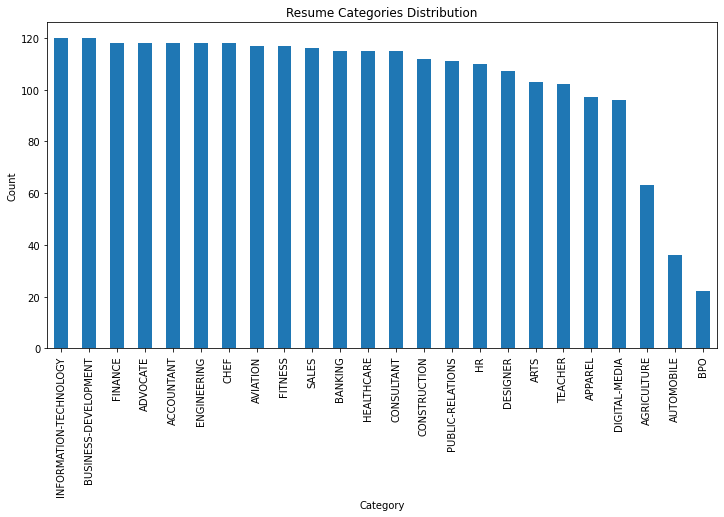

In [21]:
plt.figure(figsize=(12,6))

df['Category'].value_counts().plot(kind='bar')

plt.title("Resume Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

**2. Resume Length Analysis**

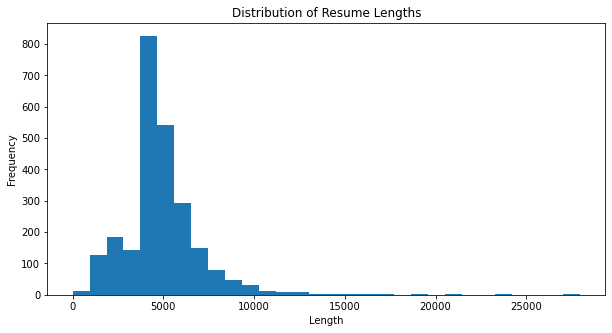

In [25]:
df['Resume_Length'] = df['Cleaned_Resume'].apply(len)

plt.figure(figsize=(10,5))

plt.hist(df['Resume_Length'], bins=30)

plt.title("Distribution of Resume Lengths")

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.show()

# 🤖 4. MACHINE LEARNING


Machine learning models cannot understand raw text.

I started by first converting text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF assigns importance scores to words based on how unique they are across resumes.

After vectorization, I trained a classification model to predict resume categories.

In [ ]:
# 1. Label Encoding

encoder = LabelEncoder()
y = encoder.fit_transform(df['Category'])

In [66]:
# 2. CLEAN DATA
df = df.dropna(subset=["Feature", "Category"])
df["Feature"] = df["Feature"].astype(str)

X = df["Feature"]
y = df["Category"]

# 3. SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:

# 4. TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# **📈 5. MODEL EVALUATION**

After training, I evaluated how well the model performs on unseen resumes.

Common metrics:

- Accuracy
- Precision
- Recall
- F1 Score

In [69]:
# 5.MODEL
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train_vec, y_train)

# 6. PREDICT
predictions = model.predict(X_test_vec)

In [70]:
print(classification_report(y_test, predictions))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.70      0.90      0.79        29
              ADVOCATE       0.88      0.70      0.78        30
           AGRICULTURE       0.33      0.12      0.18         8
               APPAREL       0.58      0.35      0.44        20
                  ARTS       0.25      0.06      0.09        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.75      0.86      0.80        21
               BANKING       0.73      0.70      0.71        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.67      0.44      0.53        27
                  CHEF       0.76      0.79      0.78        24
          CONSTRUCTION       0.85      0.82      0.84        34
            CONSULTANT       0.83      0.25      0.38        20
              DESIGNER       0.65      0.89      0.76        19
         DIGITAL-MEDIA       0.76      

c:\Users\User\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


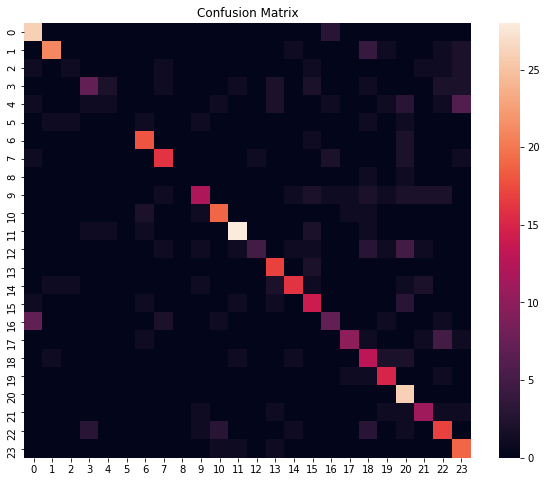

In [71]:
# Confusion Matrix


cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(10,8))

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()

# **💾 6. SAVE MODEL**

Saving the model allows it to be reused during deployment without retraining.

In [52]:
# Save the Model
pickle.dump(model, open("resume_classifier.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(encoder, open("label_encoder.pkl", "wb"))

print(" Model trained and saved correctly!")

 Model trained and saved correctly!
